# 01 — Language Detection Module

## 1. Imports

In [2]:
import os
import re
import json
import pandas as pd
import numpy as np
import dill
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

e:\final_final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Project Paths

In [3]:
MODEL_DIR = r"E:/final_final/models"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "language_detection_tfidf_linearsvc.pkl")
METRICS_PATH = os.path.join(MODEL_DIR, "language_detection_metrics.json")

print("MODEL_PATH:", MODEL_PATH)
print("METRICS_PATH:", METRICS_PATH)


MODEL_PATH: E:/final_final/models\language_detection_tfidf_linearsvc.pkl
METRICS_PATH: E:/final_final/models\language_detection_metrics.json


## 3. Load Dataset

In [4]:
# loading data from Hugging Face Hub (papluca/language-identification))
hf_dataset = load_dataset("papluca/language-identification")

# convert to pandas DataFrames
df_train = pd.DataFrame(hf_dataset['train'])
df_val = pd.DataFrame(hf_dataset['validation'])
df_test = pd.DataFrame(hf_dataset['test'])

print("Hugging Face Train Shape:", df_train.shape)
print("Hugging Face Validation Shape:", df_val.shape)
print("Hugging Face Test Shape:", df_test.shape)
df_train.head()


e:\final_final\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hp\.cache\huggingface\hub\datasets--papluca--language-identification. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 93335.97 examples/s]


Hugging Face Train Shape: (70000, 2)
Hugging Face Validation Shape: (10000, 2)
Hugging Face Test Shape: (10000, 2)


,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


## 4. EDA

In [5]:
print("Columns:", df_train.columns.tolist())
print("\nData types:")
print(df_train.dtypes)

print("\nMissing values:")
print(df_train.isna().sum())

Columns: ['labels', 'text']

Data types:
labels    str
text      str
dtype: object

Missing values:
labels    0
text      0
dtype: int64


Number of languages: 20


,count
labels,
ar,3500
bg,3500
de,3500
el,3500
en,3500
es,3500
fr,3500
hi,3500
it,3500


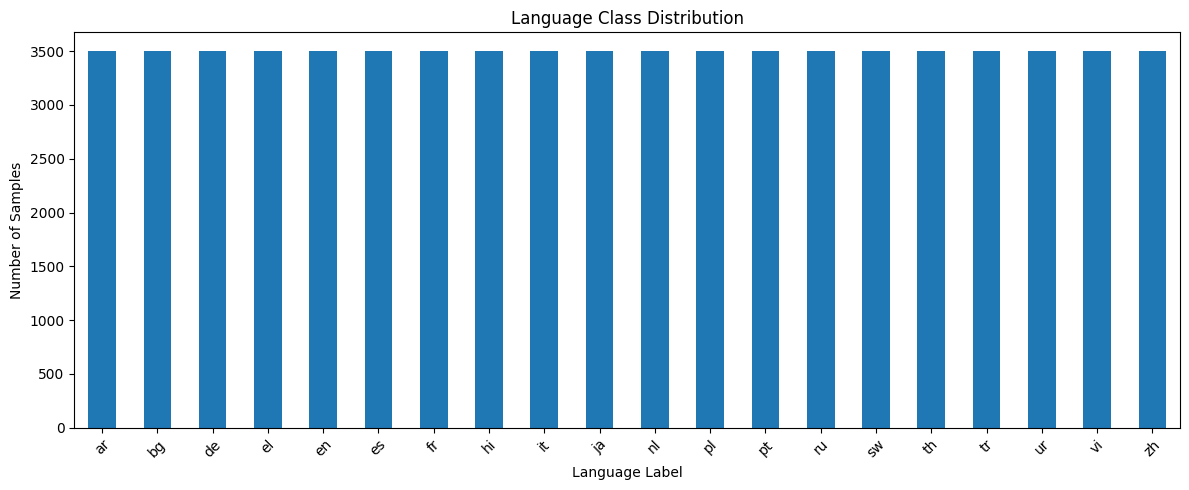

In [6]:
# class distribution

label_counts = df_train["labels"].value_counts().sort_index()

print("Number of languages:", df_train["labels"].nunique())
display(label_counts.to_frame("count"))

plt.figure(figsize=(12, 5))
label_counts.plot(kind="bar")
plt.title("Language Class Distribution")
plt.xlabel("Language Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,char_len,word_len
count,70000.000000,70000.000000
mean,110.861414,19.749257
std,103.106240,19.430456
min,2.000000,1.000000
25%,47.000000,7.000000
50%,82.000000,14.000000
75%,143.000000,26.000000
max,2422.000000,420.000000


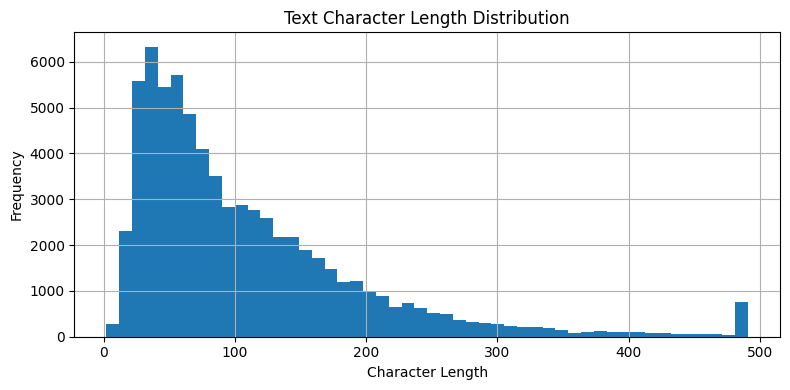

In [7]:

df_train["char_len"] = df_train["text"].astype(str).str.len()
df_train["word_len"] = df_train["text"].astype(str).str.split().str.len()

display(df_train[["char_len", "word_len"]].describe())

plt.figure(figsize=(8, 4))
df_train["char_len"].clip(upper=df_train["char_len"].quantile(0.99)).hist(bins=50)
plt.title("Text Character Length Distribution")
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 5. Data Clean
make light text cleaning for language detection

In [8]:
def clean_text(text):
    
    if not isinstance(text, str):
        return ""
    
    # convert to lower
    text = text.lower()
    # remove links
    text = re.sub(r'https?://\s*\S+|www\.\S+', '', text)
    # remove emojes, punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

## 6. Data Augmentation
short sentence generation strategy for training data only to prevent leakage

In [9]:
print("Original data size", df_train.shape)

augmented_data = []

for idx, row in df_train.iterrows():
    text = str(row['text'])
    label = row['labels']
    words = text.split()
    
    if len(words) >= 4:
        short_1 = " ".join(words[:2])
        short_2 = " ".join(words[len(words)//2 : (len(words)//2)+2])
        short_3 = " ".join(words[:3])
        
        if len(short_1) > 2: augmented_data.append({"text": short_1, "labels": label})
        if len(short_2) > 2: augmented_data.append({"text": short_2, "labels": label})
        if len(short_3) > 2: augmented_data.append({"text": short_3, "labels": label})
        
    if len(words) >= 2:
        word_1 = words[0].strip(",.!?")
        word_2 = words[1].strip(",.!?")
        
        if len(word_1) >= 2: augmented_data.append({"text": word_1, "labels": label})
        if len(word_2) >= 2: augmented_data.append({"text": word_2, "labels": label})

# Merge the generated data with the training and remove duplicates
df_short = pd.DataFrame(augmented_data)
df_train_augmented = pd.concat([df_train, df_short], ignore_index=True)
df_train_augmented = df_train_augmented.drop_duplicates(subset=['text']).reset_index(drop=True)

print("Total data size after adding short sentences to the training data:", df_train_augmented.shape)


Original data size (70000, 4)
Total data size after adding short sentences to the training data: (257163, 4)


In [10]:
df_train_augmented['clean_text'] = df_train_augmented['text'].apply(clean_text)
df_val['clean_text'] = df_val['text'].apply(clean_text)
df_test['clean_text'] = df_test['text'].apply(clean_text)

X_train = df_train_augmented["clean_text"]
y_train = df_train_augmented["labels"]

X_val = df_val["clean_text"]
y_val = df_val["labels"]

X_test = df_test["clean_text"]
y_test = df_test["labels"]

print(f"X_train Size: {X_train.shape[0]}")
print(f"X_val Size:   {X_val.shape[0]}")
print(f"X_test Size:  {X_test.shape[0]}")

X_train Size: 257163
X_val Size:   10000
X_test Size:  10000


## 7. Models Pipelines

In [11]:
tfidf_config = {
    'analyzer': 'char',
    'ngram_range': (2, 5),
    'max_features': 50000
}

# 1. Logistic Regression Pipeline
logreg_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(**tfidf_config)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 2. LinearSVC Pipeline
svc_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(**tfidf_config)),
    ('classifier', LinearSVC(random_state=42))
])

## 8. Training Models

In [12]:
print("Training Logistic Regression")
logreg_pipeline.fit(X_train, y_train)
logreg_val_acc = accuracy_score(y_val, logreg_pipeline.predict(X_val))
print(f"Logistic Regression Validation Accuracy: {logreg_val_acc:.4f}\n")

Training Logistic Regression
Logistic Regression Validation Accuracy: 0.9934



In [13]:
print("Training LinearSVC")
svc_pipeline.fit(X_train, y_train)
svc_val_acc = accuracy_score(y_val, svc_pipeline.predict(X_val))
print(f"LinearSVC Validation Accuracy: {svc_val_acc:.4f}\n")

Training LinearSVC
LinearSVC Validation Accuracy: 0.9943



## 9. Compare Models

In [14]:
# compare based on validation
results = pd.DataFrame({
    "Model": ["TF-IDF + LogisticRegression", "TF-IDF + LinearSVC"],
    "Validation Accuracy": [logreg_val_acc, svc_val_acc]
}).sort_values("Validation Accuracy", ascending=False)

display(results)

# select best model
if svc_val_acc >= logreg_val_acc:
    best_model = svc_pipeline
    best_model_name = "TF-IDF + LinearSVC"
    best_acc = svc_val_acc
else:
    best_model = logreg_pipeline
    best_model_name = "TF-IDF + LogisticRegression"
    best_acc = logreg_val_acc

print(f" Best Model Selected: {best_model_name} with Val Accuracy: {best_acc:.4f}")

,Model,Validation Accuracy
1,TF-IDF + LinearSVC,0.9943
0,TF-IDF + LogisticRegression,0.9934


 Best Model Selected: TF-IDF + LinearSVC with Val Accuracy: 0.9943


## 10. Evaluation on Test Set

In [15]:
print(f"Evaluating {best_model_name}")

y_pred_test = best_model.predict(X_test)
final_test_acc = accuracy_score(y_test, y_pred_test)

print(f"\nTest Accuracy: {final_test_acc:.4f}")
print("\nFinal Classification Report:\n")
print(classification_report(y_test, y_pred_test))

Evaluating TF-IDF + LinearSVC

Test Accuracy: 0.9955

Final Classification Report:

              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       1.00      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       1.00      1.00      1.00       500
          es       1.00      1.00      1.00       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.97      0.98       500
          it       0.99      0.99      0.99       500
          ja       1.00      1.00      1.00       500
          nl       0.98      1.00      0.99       500
          pl       1.00      1.00      1.00       500
          pt       1.00      1.00      1.00       500
          ru       1.00      1.00      1.00       500
          sw       0.97      1.00      0.98       500
          th       1.00      1.00      1.00       5

## 11. Save Best Model

In [16]:
with open(MODEL_PATH, "wb") as f:
    dill.dump(best_model, f)

metrics = {
    "best_model": best_model_name,
    "validation_accuracy": float(best_acc),
    "test_accuracy": float(final_test_acc),
    "num_classes": int(df_train["labels"].nunique()),
    "classes": sorted(df_train["labels"].unique().tolist()),
    "train_size_augmented": int(X_train.shape[0]),
    "test_size": int(X_test.shape[0]),
    "vectorizer": "TfidfVectorizer",
    "analyzer": "char",
    "ngram_range": [2, 5],
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print(f"Model saved to: {MODEL_PATH}")
print(f"Metrics saved to: {METRICS_PATH}")

Model saved to: E:/final_final/models\language_detection_tfidf_linearsvc.pkl
Metrics saved to: E:/final_final/models\language_detection_metrics.json


## 12. Load Model and Test Predictions

In [17]:
# Hybrid Prediction Function
SHORT_WORDS_FALLBACK = {
    "hi": "en", "hello": "en", "hey": "en",
    "مرحبا": "ar", "هلا": "ar", "سلام": "ar",
    "hola": "es", "bonjour": "fr", "salut": "fr",
    "ciao": "it", "hallo": "de"
}

def predict_language(text: str) -> str:
    cleaned = clean_text(text).strip().lower()
    
    if cleaned in SHORT_WORDS_FALLBACK:
        return SHORT_WORDS_FALLBACK[cleaned]
    
    return best_model.predict([cleaned])[0]

print("Testing Hybrid Predictor:")
print(f"'hello, how are you' -> {predict_language('hello, how are you')}")
print(f"'hello' -> {predict_language('hello')}")
print(f"'hi' -> {predict_language('hi')}")
print(f"'أنا أشعر بالتوتر والقلق'-> {predict_language('أنا أشعر بالتوتر والقلق')}")

Testing Hybrid Predictor:
'hello, how are you' -> en
'hello' -> en
'hi' -> en
'أنا أشعر بالتوتر والقلق'-> ar


In [18]:
examples = [
    "Hello, how are you today?",
    "أنا أشعر بالتوتر والقلق",
    "Je me sens très fatigué aujourd'hui",
    "Estoy muy triste y necesito ayuda",
    "我今天感觉很焦虑",
    "Ich fühle mich gestresst"
]

for example in examples:
    print(f"{example}  -->  {predict_language(example)}")

Hello, how are you today?  -->  en
أنا أشعر بالتوتر والقلق  -->  ar
Je me sens très fatigué aujourd'hui  -->  fr
Estoy muy triste y necesito ayuda  -->  es
我今天感觉很焦虑  -->  zh
Ich fühle mich gestresst  -->  de


In [19]:
predict_language("قلق")

'ar'